# <center> FTIR Spectra: Classification of Breast Tissue Biopsy Cores (Malignant/Non-malignant)</center>

## Dataset

In [1]:
import numpy as np
import os
import scipy.io


def load_data():
    data_location = '/Users/hugoboland/multimodal/processed-data/'
    data_extension = '.mat'
    train_name = 'PreProcessingEpithelium'
    independent_test_name = 'PreProcessingEpitheliumIndependent'
    core_information_name = 'CoreInformation'

    # Load dataset from .MAT files
    train = scipy.io.loadmat(os.path.join(data_location, train_name + data_extension))
    independent = scipy.io.loadmat(os.path.join(data_location, independent_test_name + data_extension))
    core_information = scipy.io.loadmat(os.path.join(data_location, core_information_name + data_extension))

    # Prepare training set: data (13080 spectra, 561 features) and labels (1 - malignant, 2 - normal)
    y_train = np.concatenate((np.ones((train['groupsize'][0, 0], 1)), np.ones((train['groupsize'][0, 1], 1)) * 2))
    x_train = train['output']
    train_groupsize = train['groupsize']

    # Separate training data into cancerous (10464 spectra) and normal (2616 spectra)
    x_cancer = x_train[:train_groupsize[0][0], :]
    x_normal = x_train[train_groupsize[0][0]:np.sum(train_groupsize), :]

    # Map spectra in training data to corresponding biopsy core: 
    # 40 biopsy cores (32 malignant, 8 normal); 327 spectra for each core
    cancer_core_information = core_information['CoreInformation'][:train_groupsize[0][0], :]
    normal_core_information = core_information['CoreInformation'][train_groupsize[0][0]:np.sum(train_groupsize), :]

    # Prepare independent test set: data (1690 spectra, 561 features) and labels (1 - malignant, 2 normal)
    # 1352 spectra malignant, 338 spectra normal
    y_independent_test = independent['YIn']
    x_independent_test = independent['In']
    independent_groupsize = [np.count_nonzero(y_independent_test == 1), np.count_nonzero(y_independent_test == 2)]

    # Map spectra in independent test data to corresponding biopsy core:
    # 10 biopsy cores (8 malignant, 2 normal); 169 spectra for each core
    ind_cores = np.repeat(np.arange(1, 11), 169)
    ind_cancer_cores = np.repeat(np.arange(1, 9), 169)
    ind_normal_cores = np.repeat(np.arange(9, 11), 169)

    print("Data loaded successfully.")

    return (
        x_train, y_train, x_cancer, x_normal, x_independent_test, y_independent_test, 
        train_groupsize, independent_groupsize, cancer_core_information, 
        normal_core_information, ind_cores, ind_cancer_cores, ind_normal_cores
    )

## Explore AdaBoost and Random Forests on Unbalanced Datasets (Spectra-level Classification)

In [2]:
(
  x_train, y_train, x_cancer, x_normal, x_independent_test, y_independent_test, train_groupsize, independent_groupsize, 
  cancer_core_information, normal_core_information, ind_cores, ind_cancer_cores, ind_normal_cores
) = load_data()

Data loaded successfully.


In [3]:
from sklearn.model_selection import train_test_split

# Select training data with different proportions from each core
# Total of 4500 malignant spectra, 2500 non-malignant spectra

cancer_data_input = []
cancer_patient_input = []
normal_data_input = []
normal_patient_input = []

input_cancer_information = cancer_core_information.copy()
input_normal_information = normal_core_information.copy()

for i in range(5):
    # Malignant (cancer) spectra selection
    if i == 0:
        cancer_proportion = 2500 / len(input_cancer_information)
    else:
        cancer_proportion = 500 / len(input_cancer_information)

    cancer_chosen, cancer_remain, cancer_patient_chosen, cancer_patient_remain = train_test_split(
        x_cancer, input_cancer_information, test_size=1-cancer_proportion, stratify=input_cancer_information
    )

    cancer_data_input.append(cancer_chosen)
    cancer_patient_input.append(cancer_patient_chosen)

    x_cancer = cancer_remain
    input_cancer_information = cancer_patient_remain

    # Non-malignant (normal) spectra selection
    normal_proportion = 500 / len(input_normal_information)

    normal_chosen, normal_remain, normal_patient_chosen, normal_patient_remain = train_test_split(
        x_normal, input_normal_information, test_size=1-normal_proportion, stratify=input_normal_information
    )

    normal_data_input.append(normal_chosen)
    normal_patient_input.append(normal_patient_chosen)

    x_normal = normal_remain
    input_normal_information = normal_patient_remain

for i in range(5):
    print(f'Selection {i + 1}:')
    print(f'  Malignant data shape: {cancer_data_input[i].shape}')
    print(f'  Non-malignant data shape: {normal_data_input[i].shape}')
    print(f'  Total spectra samples: {cancer_data_input[i].shape[0] + normal_data_input[i].shape[0]}')
    print(f'  Features (wavenumbers): {cancer_data_input[i].shape[1]}\n')



Selection 1:
  Malignant data shape: (2500, 561)
  Non-malignant data shape: (500, 561)
  Total spectra samples: 3000
  Features (wavenumbers): 561

Selection 2:
  Malignant data shape: (500, 561)
  Non-malignant data shape: (500, 561)
  Total spectra samples: 1000
  Features (wavenumbers): 561

Selection 3:
  Malignant data shape: (500, 561)
  Non-malignant data shape: (500, 561)
  Total spectra samples: 1000
  Features (wavenumbers): 561

Selection 4:
  Malignant data shape: (500, 561)
  Non-malignant data shape: (500, 561)
  Total spectra samples: 1000
  Features (wavenumbers): 561

Selection 5:
  Malignant data shape: (500, 561)
  Non-malignant data shape: (500, 561)
  Total spectra samples: 1000
  Features (wavenumbers): 561



In [4]:
# Separate selected spectra data into groups
# i.e. 1 training dataset for each unbalanced class ratio: 50:50, 60:40, 70:30, 80:20, 90:10

class_ratios = ['50:50', '60:40', '70:30', '80:20', '90:10']

cancer_train_input = []
cancer_train_patient = []
normal_train_input = []
normal_train_patient = []
un_balanced = []
un_patient = []
un_groupsize = []
un_balanced_y = []

cancer_cumulative_data = []
cancer_cumulative_patient = []
normal_cumulative_data = []
normal_cumulative_patient = []

for i in range(5):
    # Malignant (cancer) data
    if i == 0:
        cancer_cumulative_data = cancer_data_input[i]
        cancer_cumulative_patient = cancer_patient_input[i]
    else:
        cancer_cumulative_data = np.vstack((cancer_cumulative_data, cancer_data_input[i]))
        cancer_cumulative_patient = np.concatenate((cancer_cumulative_patient, cancer_patient_input[i]))
    
    cancer_train_input.append(cancer_cumulative_data)
    cancer_train_patient.append(cancer_cumulative_patient)

    # Non-malignant (normal) data
    if i == 0:
        normal_cumulative_data = normal_data_input[i]
        normal_cumulative_patient = normal_patient_input[i]
    else:
        normal_cumulative_data = np.vstack((normal_cumulative_data, normal_data_input[i]))
        normal_cumulative_patient = np.concatenate((normal_cumulative_patient, normal_patient_input[i]))
    
    normal_train_input.append(normal_cumulative_data)
    normal_train_patient.append(normal_cumulative_patient)

# Create unbalanced datasets
for i in range(5):
    un_balanced.append(np.vstack((cancer_train_input[i], normal_train_input[4 - i])))
    un_patient.append(np.concatenate((cancer_train_patient[i], normal_train_patient[4 - i])))
    un_groupsize.append([cancer_train_input[i].shape[0], normal_train_input[4 - i].shape[0]])
    
    # Labels: 1 - malignant; 2 - non-malignat
    y = np.ones(un_groupsize[i][0] + un_groupsize[i][1])
    y[un_groupsize[i][0]:] = 2
    un_balanced_y.append(y)

for i in range(5):
    print(f'Training Dataset {i+1} (Class Ratio {class_ratios[i]}):')
    print(f'  Shape: {un_balanced[i].shape}')
    print(f'  Malignant spectra samples: {un_groupsize[i][0]}')
    print(f'  Non-malignant spectra samples: {un_groupsize[i][1]}')
    print(f'  Total spectra samples: {un_balanced[i].shape[0]}')
    print(f'  Features (Wvn): {un_balanced[i].shape[1]}\n')

Training Dataset 1 (Class Ratio 50:50):
  Shape: (5000, 561)
  Malignant spectra samples: 2500
  Non-malignant spectra samples: 2500
  Total spectra samples: 5000
  Features (Wvn): 561

Training Dataset 2 (Class Ratio 60:40):
  Shape: (5000, 561)
  Malignant spectra samples: 3000
  Non-malignant spectra samples: 2000
  Total spectra samples: 5000
  Features (Wvn): 561

Training Dataset 3 (Class Ratio 70:30):
  Shape: (5000, 561)
  Malignant spectra samples: 3500
  Non-malignant spectra samples: 1500
  Total spectra samples: 5000
  Features (Wvn): 561

Training Dataset 4 (Class Ratio 80:20):
  Shape: (5000, 561)
  Malignant spectra samples: 4000
  Non-malignant spectra samples: 1000
  Total spectra samples: 5000
  Features (Wvn): 561

Training Dataset 5 (Class Ratio 90:10):
  Shape: (5000, 561)
  Malignant spectra samples: 4500
  Non-malignant spectra samples: 500
  Total spectra samples: 5000
  Features (Wvn): 561



In [5]:
import time
from collections import defaultdict
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import confusion_matrix


def format_time(seconds):
    minutes, seconds = divmod(int(seconds), 60)
    hours, minutes = divmod(minutes, 60)
    return f'{hours:02d}:{minutes:02d}:{seconds:02d}'

def calculate_accuracies(confusion_matrix):
    malignant_accuracy = confusion_matrix[0, 0] / np.sum(confusion_matrix[0, :])  # TP / (TP + FN)
    non_malignant_accuracy = confusion_matrix[1, 1] / np.sum(confusion_matrix[1, :])  # TN / (TN + FP)
    return malignant_accuracy, non_malignant_accuracy

def run_classifier(classifier, X, y, X_independent, y_independent):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y)

    # Train AdaBoost or Random Forests model
    if classifier == 'AdaBoost':
        model = AdaBoostClassifier(n_estimators=500, learning_rate=1)
    elif classifier == 'Random Forests':
        model = RandomForestClassifier(n_estimators=500, n_jobs=-1)

    model.fit(X_train, y_train)

    # Evaluate on validation set
    y_pred_val = model.predict(X_val)
    validation = confusion_matrix(y_val, y_pred_val)
    
    # Evaluate on independent test set
    y_pred_independent = model.predict(X_independent)
    independent = confusion_matrix(y_independent, y_pred_independent)
    importance = model.feature_importances_
    y_pred_proba_independent = model.predict_proba(X_independent)

    model_results = {
        'model': model,
        'validation': validation,
        'independent_test': independent,
        'importance': importance,
        'y_true_independent': y_independent,
        'y_pred_proba_independent': y_pred_proba_independent
    }

    return model_results


classifiers = ['AdaBoost', 'Random Forests']
results = {clf: defaultdict(list) for clf in classifiers}
runs = 5

print('Starting Model Training and Evaluation')
print('---------------------------------------')

total_start_time = time.time()

# 5 separate runs 
for run in range(runs):
    run_start_time = time.time()
    print(f'\nRun {run + 1}/{runs}')
    print('-------------')

    # Random Forests or AdaBoost
    for clf in classifiers:
        # Run model with specific unbalanced class ratio
        for model_num, class_ratio in enumerate(class_ratios):
            print(f'   Training & testing {clf} model: {class_ratio} class ratio')
            # Get unbalanced training dataset for that class ratio
            X = un_balanced[model_num]
            y = un_balanced_y[model_num]
            # Train and test the model
            result = run_classifier(clf, X, y, x_independent_test, y_independent_test)
            results[clf][class_ratio].append(result)

    run_end_time = time.time()
    run_duration = run_end_time - run_start_time
    print(f'   Run {run + 1} completed in {format_time(run_duration)}')

    if run < runs - 1:
        estimated_time_remaining = (run_duration * (runs - run - 1))
        print(f'   Estimated time remaining: {format_time(estimated_time_remaining)}')

total_end_time = time.time()
total_duration = total_end_time - total_start_time

print('\nTraining and Evaluation completed.')
print(f'Total time: {format_time(total_duration)}')

Starting Model Training and Evaluation
---------------------------------------

Run 1/5
-------------
   Training & testing AdaBoost model: 50:50 class ratio
   Training & testing AdaBoost model: 60:40 class ratio
   Training & testing AdaBoost model: 70:30 class ratio
   Training & testing AdaBoost model: 80:20 class ratio
   Training & testing AdaBoost model: 90:10 class ratio
   Training & testing Random Forests model: 50:50 class ratio
   Training & testing Random Forests model: 60:40 class ratio
   Training & testing Random Forests model: 70:30 class ratio
   Training & testing Random Forests model: 80:20 class ratio
   Training & testing Random Forests model: 90:10 class ratio
   Run 1 completed in 00:07:12
   Estimated time remaining: 00:28:51

Run 2/5
-------------
   Training & testing AdaBoost model: 50:50 class ratio
   Training & testing AdaBoost model: 60:40 class ratio
   Training & testing AdaBoost model: 70:30 class ratio
   Training & testing AdaBoost model: 80:20 clas

In [6]:
print('Results Summary')
print('---------------')

for clf in classifiers:
    print(f'\n{clf} Results (averaged across 5 runs):')

    for ratio in class_ratios:
        print(f'\n  {ratio} ratio:')
        cancer_accuracies = [calculate_accuracies(r['independent_test'])[0] for r in results[clf][ratio]]
        normal_accuracies = [calculate_accuracies(r['independent_test'])[1] for r in results[clf][ratio]]
        
        print(f'    Average Malignant Accuracy: {np.mean(cancer_accuracies):.4f} (±{np.std(cancer_accuracies):.4f})')
        print(f'    Average Non-Malignant Accuracy: {np.mean(normal_accuracies):.4f} (±{np.std(normal_accuracies):.4f})')

Results Summary
---------------

AdaBoost Results (averaged across 5 runs):

  50:50 ratio:
    Average Malignant Accuracy: 0.9553 (±0.0067)
    Average Non-Malignant Accuracy: 0.9840 (±0.0113)

  60:40 ratio:
    Average Malignant Accuracy: 0.9590 (±0.0036)
    Average Non-Malignant Accuracy: 0.9787 (±0.0054)

  70:30 ratio:
    Average Malignant Accuracy: 0.9712 (±0.0040)
    Average Non-Malignant Accuracy: 0.9698 (±0.0043)

  80:20 ratio:
    Average Malignant Accuracy: 0.9766 (±0.0057)
    Average Non-Malignant Accuracy: 0.9568 (±0.0066)

  90:10 ratio:
    Average Malignant Accuracy: 0.9895 (±0.0035)
    Average Non-Malignant Accuracy: 0.9006 (±0.0150)

Random Forests Results (averaged across 5 runs):

  50:50 ratio:
    Average Malignant Accuracy: 0.9016 (±0.0021)
    Average Non-Malignant Accuracy: 0.9728 (±0.0082)

  60:40 ratio:
    Average Malignant Accuracy: 0.9275 (±0.0022)
    Average Non-Malignant Accuracy: 0.9604 (±0.0030)

  70:30 ratio:
    Average Malignant Accuracy: 

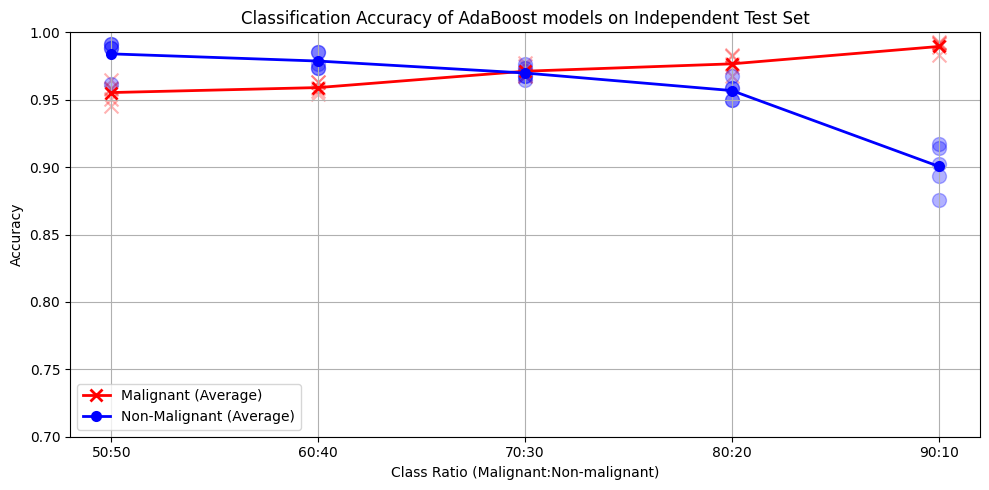

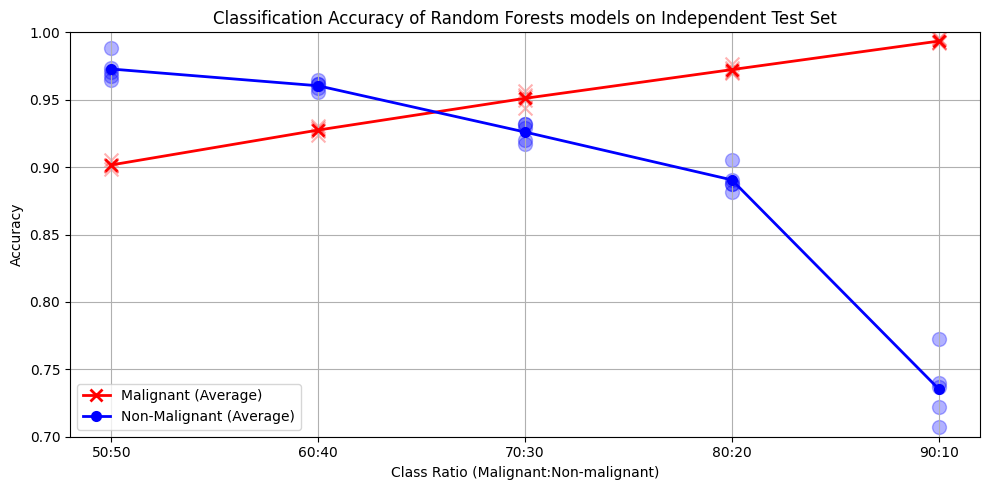

In [7]:
import matplotlib.pyplot as plt


# Plot malignant and non-malignant classification accuracies for AdaBoost and Random Forests models
def plot_model_results(results, model_name):
    avg_malignant_accuracies = []
    avg_non_malignant_accuracies = []
    all_malignant_accuracies = defaultdict(list)
    all_non_malignant_accuracies = defaultdict(list)

    for ratio in class_ratios:
        malignant_accuracies = []
        non_malignant_accuracies = []
        
        for run_result in results[ratio]:
            mal_acc, non_mal_acc = calculate_accuracies(run_result['independent_test'])
            malignant_accuracies.append(mal_acc)
            non_malignant_accuracies.append(non_mal_acc)
            
            all_malignant_accuracies[ratio].append(mal_acc)
            all_non_malignant_accuracies[ratio].append(non_mal_acc)
        
        avg_malignant_accuracies.append(np.mean(malignant_accuracies))
        avg_non_malignant_accuracies.append(np.mean(non_malignant_accuracies))

    plt.figure(figsize=(10, 5))
    for ratio in class_ratios:
        plt.scatter([ratio] * len(all_malignant_accuracies[ratio]), all_malignant_accuracies[ratio], 
                    alpha=0.3, color='red', marker='x', s=100)
        plt.scatter([ratio] * len(all_non_malignant_accuracies[ratio]), all_non_malignant_accuracies[ratio], 
                    alpha=0.3, color='blue', marker='o', s=100)

    plt.plot(class_ratios, avg_malignant_accuracies, color='red', linewidth=2, 
             marker='x', markersize=8, markeredgewidth=2, label='Malignant (Average)')
    plt.plot(class_ratios, avg_non_malignant_accuracies, color='blue', linewidth=2, 
             marker='o', markeredgewidth=2, label='Non-Malignant (Average)')

    plt.title(f'Classification Accuracy of {model_name} models on Independent Test Set')
    plt.xlabel('Class Ratio (Malignant:Non-malignant)')
    plt.ylabel('Accuracy')
    plt.xticks(class_ratios, class_ratios)
    plt.ylim(0.7, 1)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_model_results(results['AdaBoost'], 'AdaBoost')
plot_model_results(results['Random Forests'], 'Random Forests')

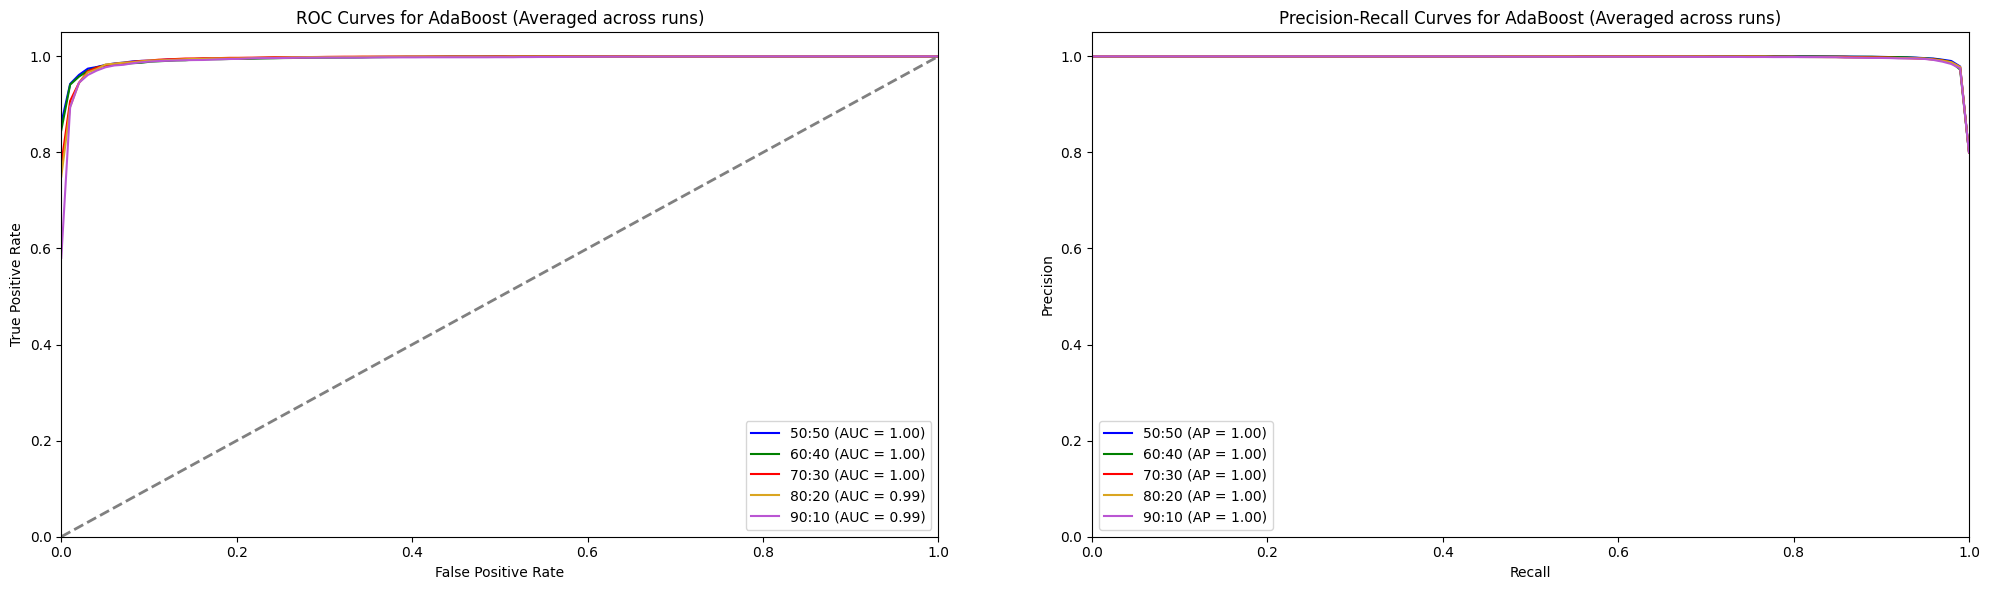

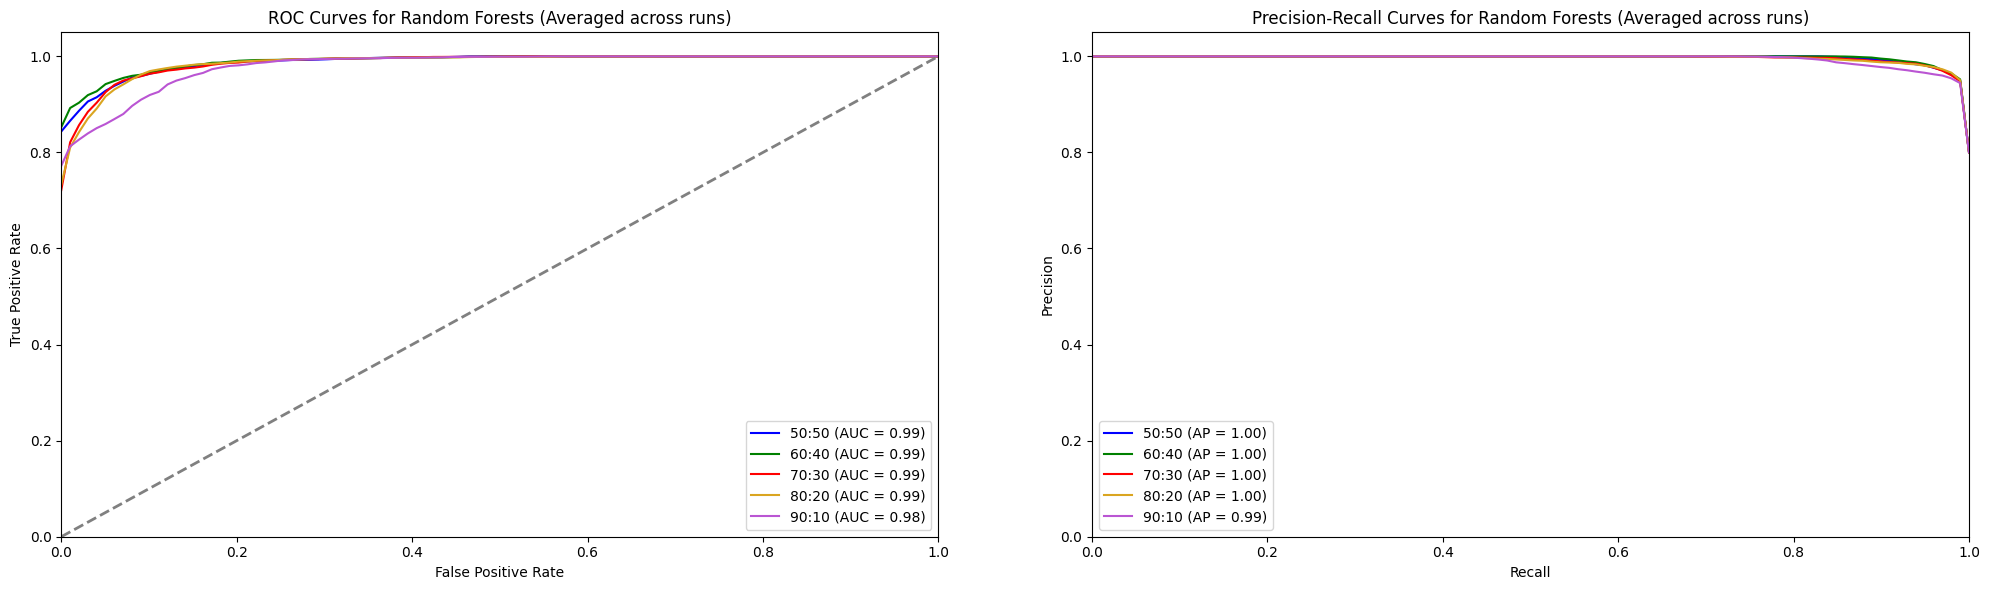

In [8]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score


# Plot ROC and PR curves for Random Forests and AdaBoost models
def plot_curves(results, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
    colours = ['blue', 'green', 'red', 'goldenrod', 'mediumorchid']

    # ROC and PR curves for each model (different class ratios; 50:50 to 90:10)
    for i, ratio in enumerate(class_ratios):
        fpr_list = []
        tpr_list = []
        roc_auc_list = []
        precision_list = []
        recall_list = []
        ap_list = []
        
        # 5 separate runs
        for run_result in results[ratio]:
            y_true = run_result['y_true_independent']
            y_true = (y_true == 1).astype(int) # Switch non-malignant label from 2 to 0
            y_pred_proba = run_result['y_pred_proba_independent'][:, 0]
            
            # ROC curve
            fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
            roc_auc = auc(fpr, tpr)
            fpr_list.append(fpr)
            tpr_list.append(tpr)
            roc_auc_list.append(roc_auc)
            
            # PR curve
            precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
            ap = average_precision_score(y_true, y_pred_proba)
            precision_list.append(precision)
            recall_list.append(recall)
            ap_list.append(ap)

        # Average over 5 runs
        mean_fpr = np.linspace(0, 1, 100)
        mean_tpr = np.mean([np.interp(mean_fpr, fpr, tpr) for fpr, tpr in zip(fpr_list, tpr_list)], axis=0)
        mean_precision = np.mean([np.interp(mean_fpr, recall[::-1], precision[::-1]) 
                                  for precision, recall in zip(precision_list, recall_list)], axis=0)
        
        mean_roc_auc = np.mean(roc_auc_list)
        mean_ap = np.mean(ap_list)
        
        ax1.plot(mean_fpr, mean_tpr, color=colours[i], label=f'{ratio} (AUC = {mean_roc_auc:.2f})')
        ax2.plot(mean_fpr, mean_precision, color=colours[i], label=f'{ratio} (AP = {mean_ap:.2f})')

    ax1.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curves for {model_name} (Averaged across runs)')
    ax1.legend(loc='lower right')
    
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'Precision-Recall Curves for {model_name} (Averaged across runs)')
    ax2.legend(loc='lower left')
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.175)
    plt.show()


plot_curves(results['AdaBoost'], 'AdaBoost')
plot_curves(results['Random Forests'], 'Random Forests')

## Final AdaBoost Model (spectra-level and core-level classification)

In [9]:
(
  x_train, y_train, x_cancer, x_normal, x_independent_test, y_independent_test, train_groupsize, independent_groupsize, 
  cancer_core_information, normal_core_information, ind_cores, ind_cancer_cores, ind_normal_cores
) = load_data()

Data loaded successfully.


In [10]:
from sklearn.model_selection import StratifiedKFold


# Malignant label: 1 -> 1; Non-malignant label: 2 -> 0 for simplicity in Python
y_train = np.where(y_train == 2, 0, 1).ravel()
y_independent_test = np.where(y_independent_test == 2, 0, 1).ravel()

# Combine training and independent test set, as we focus only on cross-validation
x_combined = np.vstack((x_train, x_independent_test))
y_combined = np.concatenate((y_train, y_independent_test))

core_ids = np.concatenate([
    np.repeat(np.arange(1, 41), 327),  # 40 cores in training set; 327 spectra per core
    np.repeat(np.arange(41, 51), 169)  # 10 cores in independent test set; 169 spectra per core
])

unique_core_ids = np.unique(core_ids)
core_labels = y_combined[np.unique(core_ids, return_index=True)[1]]

adaboost_model = AdaBoostClassifier(n_estimators=500, learning_rate=1)
#randomforest_model = RandomForestClassifier(n_estimators=500, n_jobs=-1)
kf = StratifiedKFold(n_splits=5, shuffle=True)

spectra_metrics = []
core_metrics = []
spectra_probabilities = []
spectra_true_labels = []
core_probabilities = []
core_true_labels = []

In [11]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score


start_time = time.time()
print('Starting 5-Fold Stratified Cross-Validation')
print('--------------------------------------------')

# 5-fold stratified cross validation using full dataset of 50 cores
for fold, (train_index, val_index) in enumerate(kf.split(unique_core_ids, core_labels), 1):
    fold_start_time = time.time()
    print(f'\nFold {fold}/{5}')
    print('-------------')

    train_cores = unique_core_ids[train_index]
    val_cores = unique_core_ids[val_index]
    
    train_spectra_indices = np.isin(core_ids, train_cores)
    val_spectra_indices = np.isin(core_ids, val_cores)
    x_train_fold, x_val_fold = x_combined[train_spectra_indices], x_combined[val_spectra_indices]
    y_train_fold, y_val_fold = y_combined[train_spectra_indices], y_combined[val_spectra_indices]

    shuffle_indices = np.random.permutation(len(x_train_fold))
    x_train_fold_shuffled = x_train_fold[shuffle_indices]
    y_train_fold_shuffled = y_train_fold[shuffle_indices]
    
    print('   Training AdaBoost model...')
    train_start_time = time.time()
    adaboost_model.fit(x_train_fold_shuffled, y_train_fold_shuffled)
    train_end_time = time.time()
    print(f'   Training completed in {format_time(train_end_time - train_start_time)}')

    print('   Validating model...')
    val_start_time = time.time()
    y_pred = adaboost_model.predict(x_val_fold)
    y_pred_proba = adaboost_model.predict_proba(x_val_fold)
    val_end_time = time.time()
    print(f'   Validation completed in {format_time(val_end_time - val_start_time)}')
    
    # Store spectra-level metrics for the current fold on validation subset
    spectra_metrics.append({
        'accuracy': accuracy_score(y_val_fold, y_pred),
        'auc': roc_auc_score(y_val_fold, y_pred_proba[:, 1]),
        'precision': precision_score(y_val_fold, y_pred),
        'recall': recall_score(y_val_fold, y_pred),
        'f1': f1_score(y_val_fold, y_pred)
    })
    
    spectra_probabilities.append(y_pred_proba[:, 1])
    spectra_true_labels.append(y_val_fold)
    
    # Aggregate spectra-level probabilities to core-level
    core_pred = []
    core_true = []
    fold_core_probabilities = []
    for core in val_cores:
        core_spectra_indices = core_ids[val_spectra_indices] == core
        core_proba = np.mean(y_pred_proba[core_spectra_indices], axis=0) # Aggregate by averaging
        fold_core_probabilities.append(core_proba[1])
        core_pred.append(np.argmax(core_proba))
        core_true.append(y_val_fold[core_spectra_indices][0])
    
    core_pred = np.array(core_pred)
    core_true = np.array(core_true)
    
    # Store core-level metrics for the current fold on validation subset
    core_metrics.append({
        'accuracy': accuracy_score(core_true, core_pred),
        'auc': roc_auc_score(core_true, fold_core_probabilities),
        'precision': precision_score(core_true, core_pred),
        'recall': recall_score(core_true, core_pred),
        'f1': f1_score(core_true, core_pred)
    })
    
    core_probabilities.append(np.array(fold_core_probabilities))
    core_true_labels.append(core_true)
    
    fold_end_time = time.time()
    fold_duration = fold_end_time - fold_start_time
    total_duration = fold_end_time - start_time
    estimated_time_left = (total_duration / fold) * (5 - fold)
    print(f'   Fold {fold} completed in {format_time(fold_duration)}')
    print(f'   Estimated time remaining: {format_time(estimated_time_left)}')
    print(f"   Spectra-level AUC: {spectra_metrics[-1]['auc']:.4f}")
    print(f"   Core-level AUC: {core_metrics[-1]['auc']:.4f}")

print('\nCross-validation completed.')
print(f'Total time: {format_time(time.time() - start_time)}')

Starting 5-Fold Stratified Cross-Validation
--------------------------------------------

Fold 1/5
-------------
   Training AdaBoost model...
   Training completed in 00:04:10
   Validating model...
   Validation completed in 00:00:00
   Fold 1 completed in 00:04:11
   Estimated time remaining: 00:16:45
   Spectra-level AUC: 0.9125
   Core-level AUC: 1.0000

Fold 2/5
-------------
   Training AdaBoost model...
   Training completed in 00:04:18
   Validating model...
   Validation completed in 00:00:00
   Fold 2 completed in 00:04:18
   Estimated time remaining: 00:12:44
   Spectra-level AUC: 0.9917
   Core-level AUC: 1.0000

Fold 3/5
-------------
   Training AdaBoost model...
   Training completed in 00:04:10
   Validating model...
   Validation completed in 00:00:00
   Fold 3 completed in 00:04:11
   Estimated time remaining: 00:08:27
   Spectra-level AUC: 0.9568
   Core-level AUC: 1.0000

Fold 4/5
-------------
   Training AdaBoost model...
   Training completed in 00:04:17
   Vali

## Results

In [12]:
def output_stats(name, values):
    mean = np.mean(values)
    std = np.std(values)
    print(f'{name:<25} Mean: {mean:.4f} ± {std:.4f}')


metrics = ['accuracy', 'auc', 'precision', 'recall', 'f1']
metric_names = ['Accuracies', 'AUCs', 'Precisions', 'Recalls', 'F1 Scores']

print('Spectra-level metrics (across 5 folds):')
print('-' * 48)
for metric, name in zip(metrics, metric_names):
    values = [fold_metrics[metric] for fold_metrics in spectra_metrics]
    output_stats(name, values)

print('\nCore-level metrics (across 5 folds):')
print('-' * 48)
for metric, name in zip(metrics, metric_names):
    values = [fold_metrics[metric] for fold_metrics in core_metrics]
    output_stats(name, values)

Spectra-level metrics (across 5 folds):
------------------------------------------------
Accuracies                Mean: 0.9104 ± 0.0391
AUCs                      Mean: 0.9508 ± 0.0327
Precisions                Mean: 0.9380 ± 0.0252
Recalls                   Mean: 0.9513 ± 0.0601
F1 Scores                 Mean: 0.9431 ± 0.0284

Core-level metrics (across 5 folds):
------------------------------------------------
Accuracies                Mean: 0.9600 ± 0.0490
AUCs                      Mean: 0.9875 ± 0.0250
Precisions                Mean: 0.9778 ± 0.0444
Recalls                   Mean: 0.9750 ± 0.0500
F1 Scores                 Mean: 0.9749 ± 0.0308


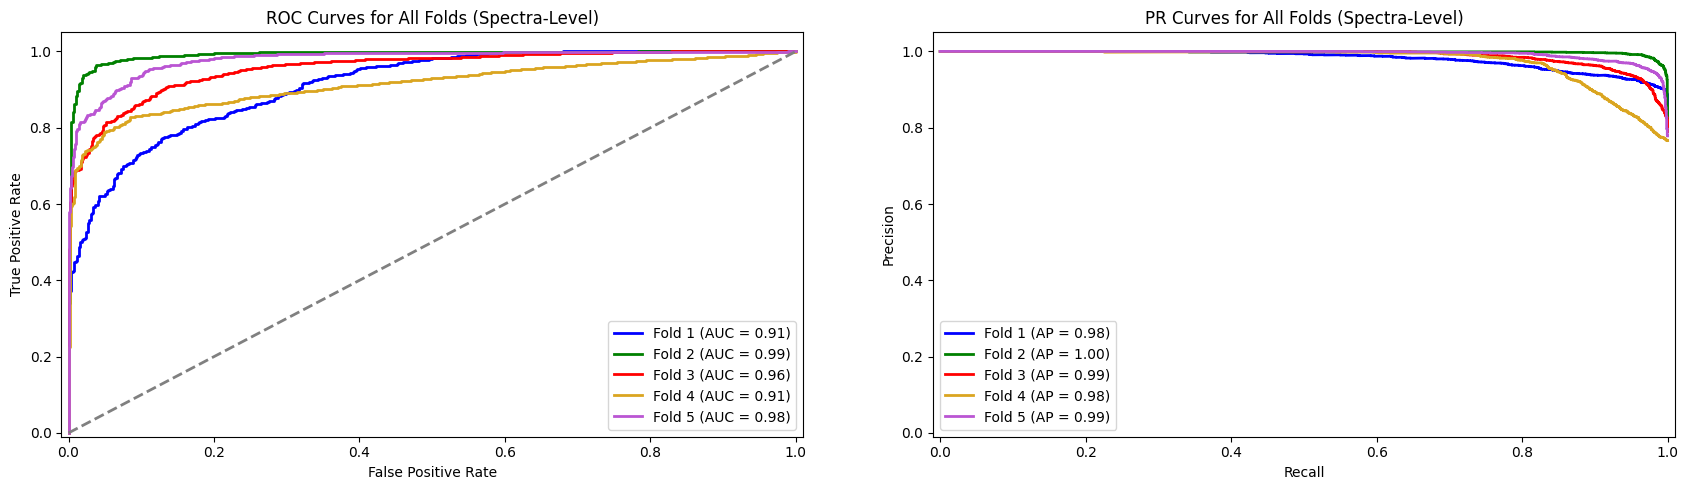

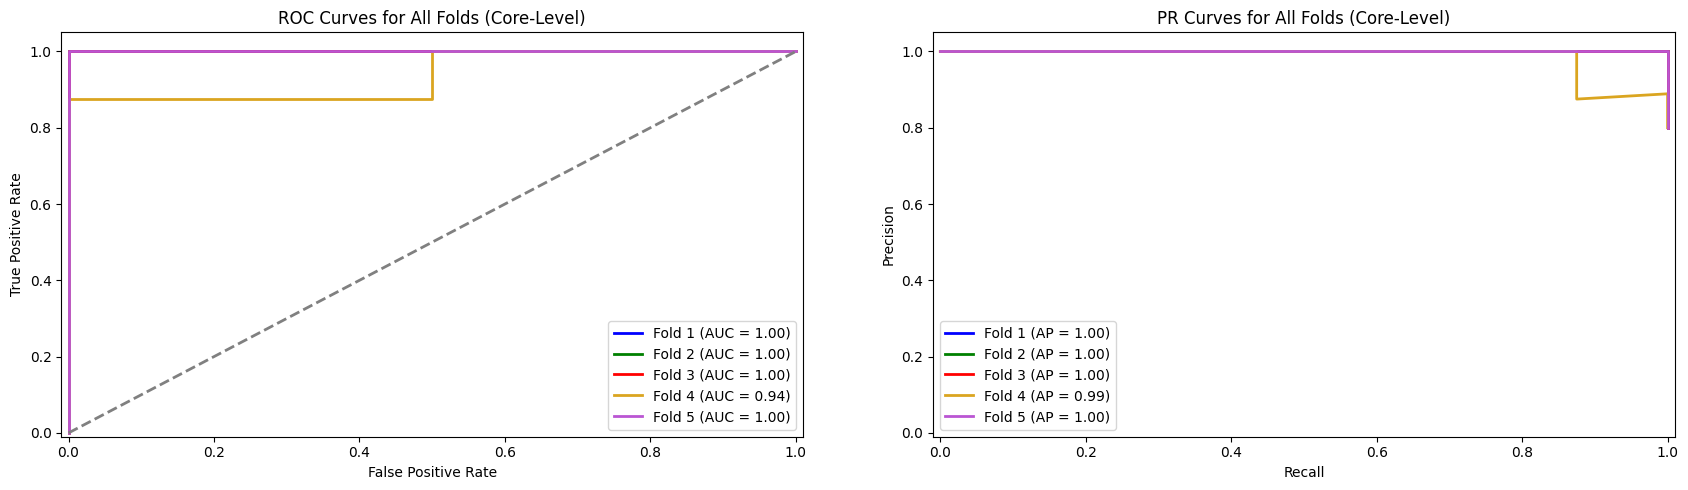

In [13]:
def plot_roc_pr_curves(probabilities, true_labels, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))
    colours = ['blue', 'green', 'red', 'goldenrod', 'mediumorchid']

    for i in range(len(probabilities)):
        y_true = true_labels[i]
        y_pred_proba = probabilities[i]

        # Plot ROC curve for each fold
        fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, color=colours[i], lw=2, label=f'Fold {i + 1} (AUC = {roc_auc:.2f})')
        
        # Plot PR curve for each fold
        precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
        avg_precision = average_precision_score(y_true, y_pred_proba)
        ax2.plot(recall, precision, color=colours[i], lw=2, label=f'Fold {i + 1} (AP = {avg_precision:.2f})')

    ax1.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    ax1.set_xlim([-0.01, 1.01])
    ax1.set_ylim([-0.01, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curves for All Folds ({title})')
    ax1.legend(loc='lower right')
    
    ax2.set_xlim([-0.01, 1.01])
    ax2.set_ylim([-0.01, 1.05])
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'PR Curves for All Folds ({title})')
    ax2.legend(loc='lower left')
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.175)
    plt.show()
    

# Plot ROC and PR curves for each folds, at spectra-level and core-level
plot_roc_pr_curves(spectra_probabilities, spectra_true_labels, 'Spectra-Level')
plot_roc_pr_curves(core_probabilities, core_true_labels, 'Core-Level')